In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [241]:
file1="train_loan_pred.csv"
file2="test_loan_pred.csv"
train=pd.read_csv(file1)
test=pd.read_csv(file2)
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [242]:
train.info()
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


(614, 13)

In [243]:
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [244]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [245]:
train.drop("Loan_ID", axis=1, inplace=True)
# Drop loan ID, it's not very useful for model

## **EDA and Preprocessing**

### **Handle Missing Values**

In [246]:
# Fill missing categorical vals with mode
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\1412183404.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)


In [247]:
# Fill missing numerical vals with median
train["LoanAmount"].fillna(train["LoanAmount"].median(), inplace=True)
train["Loan_Amount_Term"].fillna(train["Loan_Amount_Term"].median(), inplace=True)

C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2675606047.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["LoanAmount"].fillna(train["LoanAmount"].median(), inplace=True)
C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2675606047.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [248]:
# Convert "3+" to 3
train["Dependents"] = train["Dependents"].replace("3+", 3).astype(int)

### **Encoding**

In [249]:
# print(train["Loan_ID"]).unique()
print(train["Gender"].unique())
print(train["Married"].unique())
print(train["Dependents"].unique())
print(train["Self_Employed"].unique())
print(train["Education"].unique())
print(train["Property_Area"].unique())
print(train["Loan_Status"].unique())

['Male' 'Female']
['No' 'Yes']
[0 1 2 3]
['No' 'Yes']
['Graduate' 'Not Graduate']
['Urban' 'Rural' 'Semiurban']
['Y' 'N']


In [250]:
train["Gender"] = train["Gender"].map({"Male": 1, "Female": 0})
train["Married"] = train["Married"].map({"Yes": 1, "No": 0})
train["Self_Employed"] = train["Self_Employed"].map({"Yes": 1, "No": 0})
train["Education"] = train["Education"].map({"Graduate": 1, "Not Graduate": 0})
train["Loan_Status"] = train["Loan_Status"].map({"Y": 1, "N": 0})
print(train["Gender"].unique())
print(train["Married"].unique())
print(train["Self_Employed"].unique())
print(train["Education"].unique())
print(train["Loan_Status"].unique())

[1 0]
[0 1]
[0 1]
[1 0]
[1 0]


In [251]:
train = pd.get_dummies(train, columns=["Property_Area"], drop_first=True)

In [252]:
train.isnull().sum()

Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

In [253]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   ApplicantIncome          614 non-null    int64  
 6   CoapplicantIncome        614 non-null    float64
 7   LoanAmount               614 non-null    float64
 8   Loan_Amount_Term         614 non-null    float64
 9   Credit_History           614 non-null    float64
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    bool   
 12  Property_Area_Urban      614 non-null    bool   
dtypes: bool(2), float64(4), int64(7)
memory usage: 54.1 KB


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2706969674.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Loan_Status"])


<Axes: xlabel='Loan_Status', ylabel='Density'>

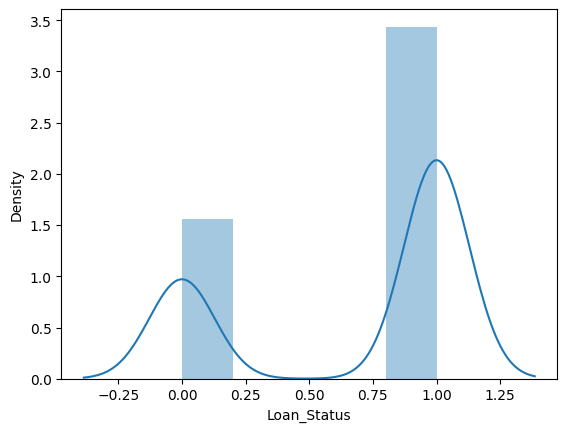

In [254]:
sns.distplot(train["Loan_Status"])

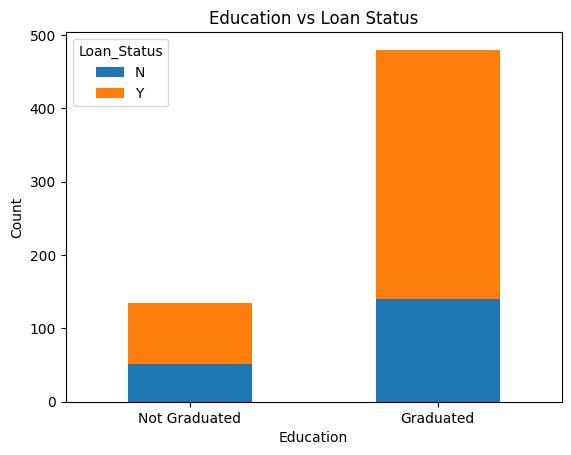

In [255]:
ct=pd.crosstab(train["Education"],train["Loan_Status"])
ct.index=ct.index.map({0:"Not Graduated",1:"Graduated"})
ct.columns=ct.columns.map({0:"N",1:"Y"})
ct.plot(kind="bar",stacked=True)
plt.xlabel("Education")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.title("Education vs Loan Status")
plt.show()

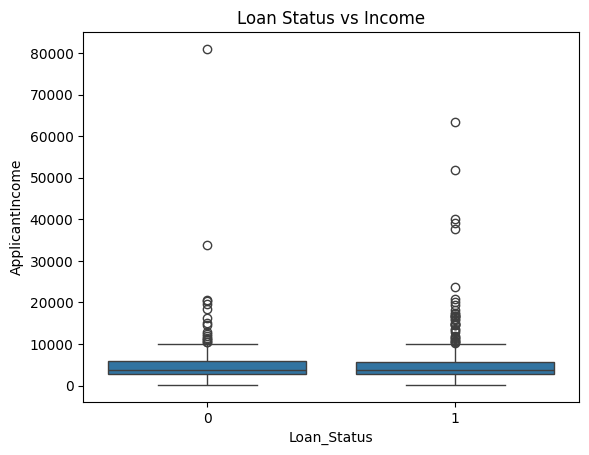

In [256]:
# Categorical vs numerical---> "box plot"
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=train)
plt.title("Loan Status vs Income")
plt.show()

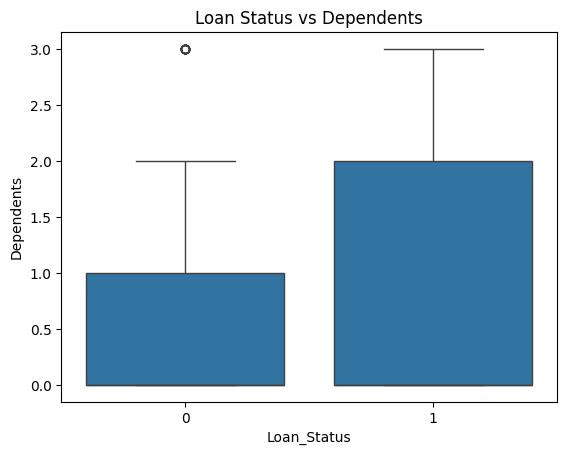

In [257]:
sns.boxplot(x="Loan_Status", y="Dependents", data=train)
plt.title("Loan Status vs Dependents")
plt.show()

(0.0, 450.0)

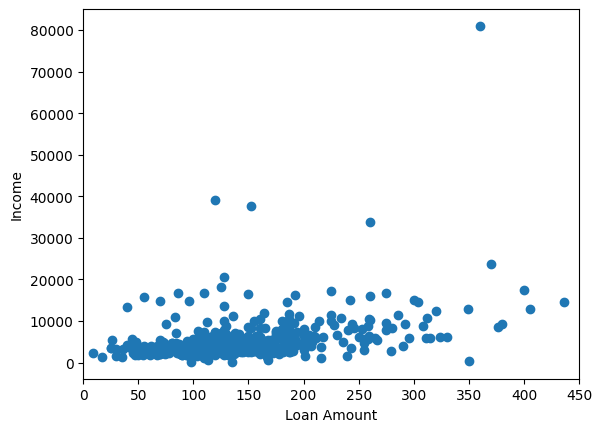

In [258]:
fig,ax=plt.subplots()
ax.scatter(x=train["LoanAmount"],y=train["ApplicantIncome"])
plt.ylabel("Income")
plt.xlabel("Loan Amount")
ax.set_xlim(0,450)

In [259]:
# train["Loan_Status"]=np.log10(train["Loan_Status"])
# sns.distplot(train.Loan_Status,fit=norm)

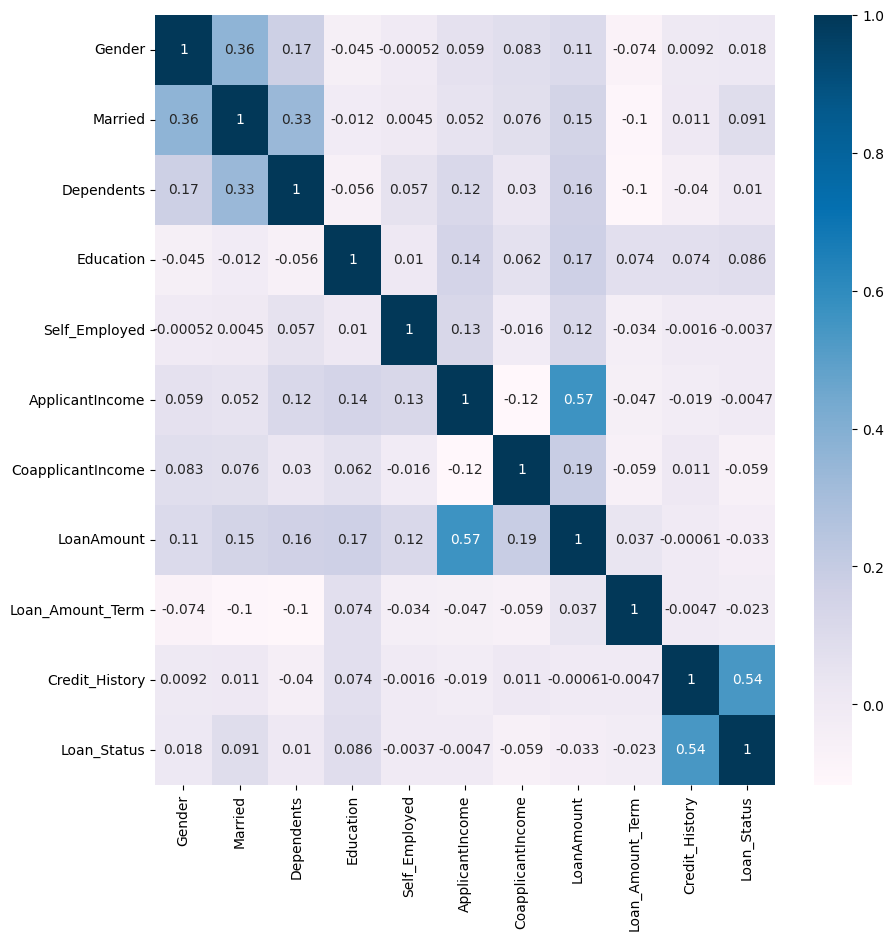

In [260]:
plt.figure(figsize=(10,10))
cor=train.select_dtypes(include=['number']).corr()
sns.heatmap(cor,annot=True,cmap=plt.cm.PuBu)
plt.show()

In [261]:
cor_target=abs(cor['Loan_Status'])
relevant_features=cor_target[cor_target>0.2]   # selecting highly correlated features
names=[index for index, value in relevant_features.items()]
# names.remove('Loan_Status')
print(names)
print(len(names))

['Credit_History', 'Loan_Status']
2


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\3419234969.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["LoanAmount"])


<Axes: xlabel='LoanAmount', ylabel='Density'>

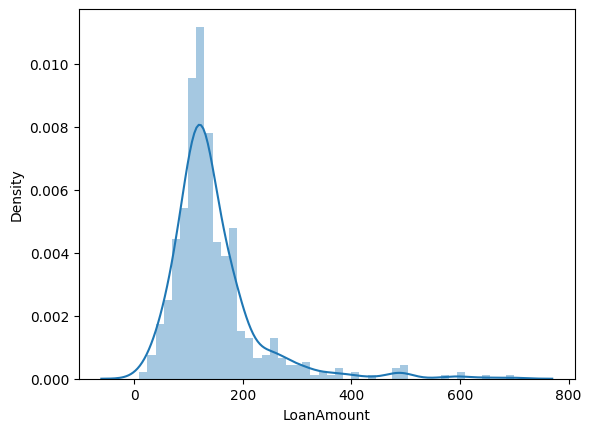

In [262]:
sns.distplot(train["LoanAmount"])

C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\3406069529.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train["Log_LoanAmount"])


<Axes: xlabel='Log_LoanAmount', ylabel='Density'>

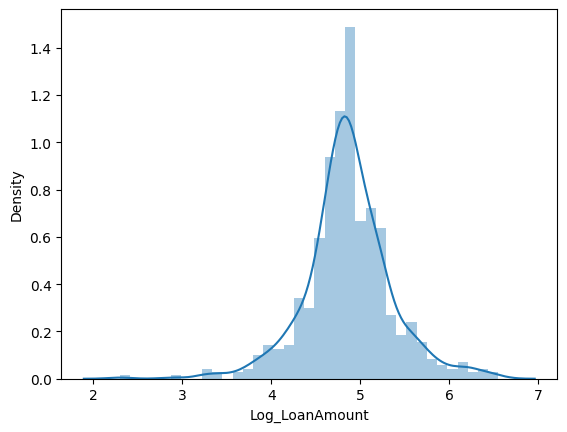

In [263]:
# Loan Amount is skewed so, 
train["Log_LoanAmount"] = np.log1p(train["LoanAmount"])
sns.distplot(train["Log_LoanAmount"])

In [264]:
train["TotalIncome"] = train["ApplicantIncome"] + train["CoapplicantIncome"]
train["Log_TotalIncome"] = np.log1p(train["TotalIncome"])

# Log transformation reduced skewness
# Made income and loan amount more normally distributed
# Helped the model learn better patterns

In [265]:
# Drop the skewed cols and only use the log cols
train.drop(["ApplicantIncome", "CoapplicantIncome", "TotalIncome", "LoanAmount"], axis=1, inplace=True)

In [266]:
train.isnull().sum()

Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
Property_Area_Semiurban    0
Property_Area_Urban        0
Log_LoanAmount             0
Log_TotalIncome            0
dtype: int64

In [267]:
y = train["Loan_Status"]
X = train.drop("Loan_Status", axis=1)

In [268]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

---
## **Modeling**

In [269]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt_model=DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train,y_train)

dt_pred=dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.6991869918699187
[[17 21]
 [16 69]]
              precision    recall  f1-score   support

           0       0.52      0.45      0.48        38
           1       0.77      0.81      0.79        85

    accuracy                           0.70       123
   macro avg       0.64      0.63      0.63       123
weighted avg       0.69      0.70      0.69       123



> Decision Tree

- Works okay
- Lower accuracy and weaker class balance
- Prone to overfitting

In [270]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(random_state=1)
rf_model.fit(X_train,y_train)

rf_pred=rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8211382113821138
[[22 16]
 [ 6 79]]
              precision    recall  f1-score   support

           0       0.79      0.58      0.67        38
           1       0.83      0.93      0.88        85

    accuracy                           0.82       123
   macro avg       0.81      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



> Random Forest (Best overall)

- Accuracy ≈ 0.82
- Good balance of precision and recall
- Much better at identifying rejected loans than Logistic Regression
- Best model overall

In [271]:
from sklearn.linear_model import LogisticRegression

logr_model=LogisticRegression(random_state=1)
logr_model.fit(X_train,y_train)

logr_pred=logr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, logr_pred))
print(confusion_matrix(y_test, logr_pred))
print(classification_report(y_test, logr_pred))

Accuracy: 0.8373983739837398
[[18 20]
 [ 0 85]]
              precision    recall  f1-score   support

           0       1.00      0.47      0.64        38
           1       0.81      1.00      0.89        85

    accuracy                           0.84       123
   macro avg       0.90      0.74      0.77       123
weighted avg       0.87      0.84      0.82       123



C:\Users\Pragya\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


> Logistic Regression

- Perfect recall for approved loans (class 1)
- But many false positives for class 0 (recall for class 0 = 0.47)
- It predicts “approved” too often

### *Model Comparision*

(0.0, 1.5)

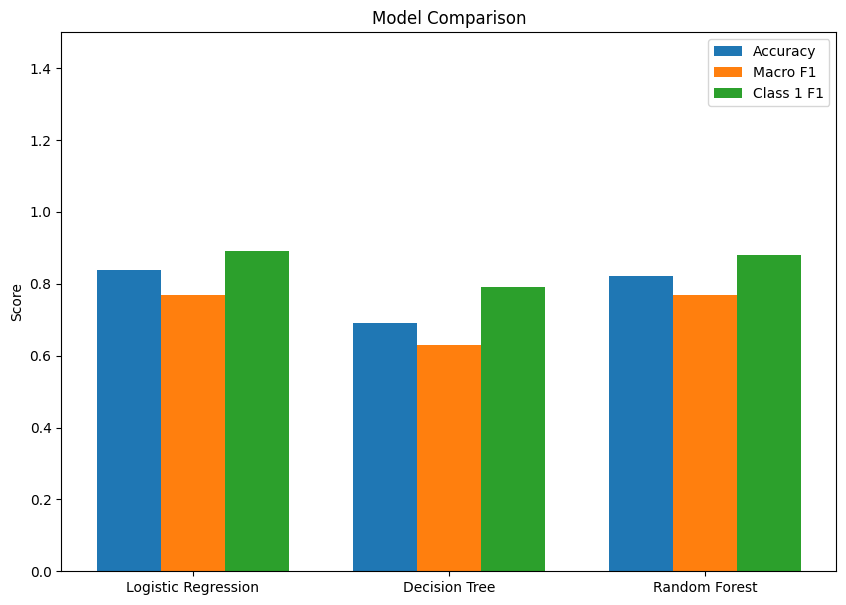

In [272]:
models=["Logistic Regression","Decision Tree","Random Forest"]

accuracy=[0.8373,0.6911,0.8211]
macro_f1=[0.77,0.63,0.77]
class1_f1=[0.89,0.79,0.88]

x=np.arange(len(models))
width=0.25

plt.figure(figsize=(10,7))

plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, macro_f1, width, label='Macro F1')
plt.bar(x + width, class1_f1, width, label='Class 1 F1')


plt.xticks(x, models)
plt.legend()
plt.ylabel('Score')
plt.title('Model Comparison')
plt.ylim(0.0, 1.5)


> Among all models, **Random Forest** achieved the best overall performance with the highest accuracy and a good balance between precision and recall for both classes. Logistic Regression achieved perfect recall for approved loans but failed to correctly identify many rejected applications. Decision Tree showed comparatively lower performance. Therefore, Random Forest was selected as the final mode

### *Feature Importance (Random Forest)*

In [273]:
import pandas as pd

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)

Log_TotalIncome            0.269142
Credit_History             0.242137
Log_LoanAmount             0.228362
Dependents                 0.059629
Loan_Amount_Term           0.041049
Property_Area_Semiurban    0.032803
Married                    0.027747
Education                  0.025885
Property_Area_Urban        0.025162
Gender                     0.025126
Self_Employed              0.022958
dtype: float64


Text(0, 0.5, 'Features')

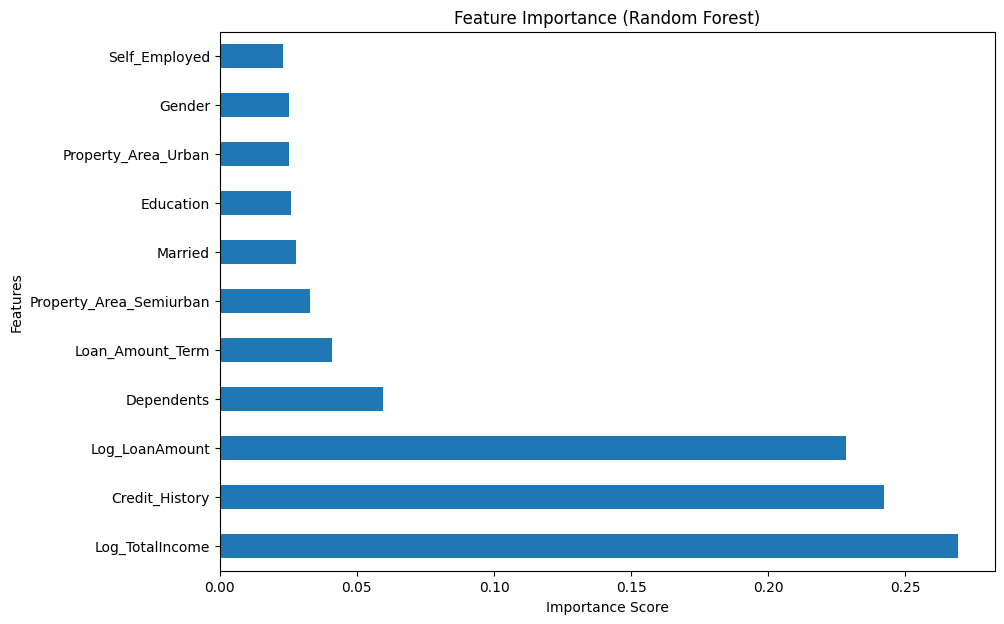

In [274]:
plt.figure(figsize=(10,7))
feat_imp.plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")


---
# **Conclusion**

- This project aimed to predict loan approval status using applicant demographic, financial, and credit-related features. After performing exploratory data analysis, missing value imputation, categorical encoding, and feature engineering, several classification models were trained and evaluated.

- EDA revealed that credit history is the most influential factor in loan approval, followed by total income and loan amount. Other variables such as gender, education, and property area showed minimal impact on the target variable.

- Three models were evaluated: Decision Tree, Logistic Regression, and Random Forest. Logistic Regression achieved perfect recall for approved loans but misclassified many rejected applications. Decision Tree showed lower overall performance and signs of overfitting. Random Forest provided the best balance between precision and recall for both classes and achieved the highest accuracy among all models.

- Based on these results, Random Forest was selected as the final model for predicting loan approval. The model demonstrates that applicants with strong credit history and higher income have a higher probability of loan approval. This approach can help financial institutions automate loan screening, reduce manual effort, and improve decision consistency.

---

---

# **Test Set Prediction**

In [275]:
test=pd.read_csv(file2)
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [276]:
test.info()
test.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


(367, 12)

In [277]:
test.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [278]:
test.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [279]:
print(test.columns.tolist())
print(train.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Log_LoanAmount', 'Log_TotalIncome']


### Encoding

In [280]:
print(test["Gender"].unique())
print(test["Married"].unique())
print(test["Dependents"].unique())
print(test["Self_Employed"].unique())
print(test["Education"].unique())
print(test["Property_Area"].unique())


['Male' 'Female' nan]
['Yes' 'No']
['0' '1' '2' '3+' nan]
['No' 'Yes' nan]
['Graduate' 'Not Graduate']
['Urban' 'Semiurban' 'Rural']


In [281]:
test["Dependents"] = test["Dependents"].replace("3+",3)

test["Gender"] = test["Gender"].replace({"Male":1,"Female":0})
test["Married"] = test["Married"].replace({"Yes":1,"No":0})
test["Education"] = test["Education"].replace({"Graduate":1,"Not Graduate":0})
test["Self_Employed"] = test["Self_Employed"].replace({"Yes":1,"No":0})


print(test["Gender"].unique())
print(test["Married"].unique())
print(test["Self_Employed"].unique())
print(test["Education"].unique())

[ 1.  0. nan]
[1 0]
[ 0.  1. nan]
[1 0]


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2418624258.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test["Gender"] = test["Gender"].replace({"Male":1,"Female":0})
C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2418624258.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test["Married"] = test["Married"].replace({"Yes":1,"No":0})
C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\2418624258.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the ol

#### Filling null values with train values

In [282]:
test['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
test['Married'].fillna(train['Married'].mode()[0], inplace=True)
test['Self_Employed'].fillna('Unknown', inplace=True)
test['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)
test['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace=True)
test['LoanAmount'].fillna(test['LoanAmount'].median(), inplace=True)

test['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
test["Dependents"] = test["Dependents"].astype(int)

test['TotalIncome'] = test['ApplicantIncome'] + test['CoapplicantIncome']
test['Log_TotalIncome'] = np.log(test['TotalIncome'])
test['Log_LoanAmount'] = np.log(test['LoanAmount'])

print(test["Dependents"].unique())

[0 1 2 3]


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\1883747184.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\1883747184.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [283]:
print(test["Gender"].unique())
print(test["Married"].unique())
print(test["Self_Employed"].unique())
print(test["Education"].unique())

[1. 0.]
[1 0]
[0.0 1.0 'Unknown']
[1 0]


In [284]:
test["Self_Employed"] = test["Self_Employed"].replace("Unknown", 0)
test["Self_Employed"] = test["Self_Employed"].astype(int)

print(test["Gender"].unique())
print(test["Married"].unique())
print(test["Self_Employed"].unique())
print(test["Education"].unique())

[1. 0.]
[1 0]
[0 1]
[1 0]


C:\Users\Pragya\AppData\Local\Temp\ipykernel_4020\1510744808.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test["Self_Employed"] = test["Self_Employed"].replace("Unknown", 0)


In [285]:
test = pd.get_dummies(test, columns=["Property_Area"], drop_first=True)


In [286]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Log_TotalIncome,Log_LoanAmount,Property_Area_Semiurban,Property_Area_Urban
0,LP001015,1.0,1,0,1,0,5720,0,110.0,360.0,1.0,5720,8.651724,4.700480,False,True
1,LP001022,1.0,1,1,1,0,3076,1500,126.0,360.0,1.0,4576,8.428581,4.836282,False,True
2,LP001031,1.0,1,2,1,0,5000,1800,208.0,360.0,1.0,6800,8.824678,5.337538,False,True
3,LP001035,1.0,1,2,1,0,2340,2546,100.0,360.0,1.0,4886,8.494129,4.605170,False,True
4,LP001051,1.0,0,0,0,0,3276,0,78.0,360.0,1.0,3276,8.094378,4.356709,False,True


In [292]:
test.isnull().sum()

Gender                     0
Married                    0
Dependents                 0
Education                  0
Self_Employed              0
Loan_Amount_Term           0
Credit_History             0
Property_Area_Semiurban    0
Property_Area_Urban        0
Log_LoanAmount             0
Log_TotalIncome            0
dtype: int64

In [293]:
test.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Log_LoanAmount', 'Log_TotalIncome'],
      dtype='object')

In [288]:
# Match the test and training columns
test = test[X.columns]
test_pred = rf_model.predict(test)
test_pred = ['Y' if i == 1 else 'N' for i in test_pred]

In [289]:
print(test_pred[:10])

['Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y']


------

## Submission Dataframe

In [291]:
test_1=pd.read_csv(file2)
submission = pd.DataFrame({
    "Loan_ID": test_1["Loan_ID"],
    "Loan_Status": test_pred
})

In [294]:
submission.to_csv("loan_predictions.csv", index=False)

In [295]:
submission["Loan_Status"].value_counts()

Loan_Status
Y    288
N     79
Name: count, dtype: int64

---
## **Conclusion**
- Test data was preprocessed using the same steps

- Random Forest model was used for prediction

- Results were exported to loan_predictions.csv